In [2]:
import re
import unicodedata
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_PATH = Path.cwd().parent.parent / "data" / "processed" / "dataset_filled_subjects_new.csv"

In [3]:
# %% [load]
# Only the columns needed for keyword trends (subject_name kept for readable plot labels).
nodes = pd.read_csv(DATA_PATH, usecols=["thesis", "year", "subject_code", "subject_name"])

nodes["year"] = pd.to_numeric(nodes["year"], errors="coerce")
nodes["subject_code"] = pd.to_numeric(nodes["subject_code"], errors="coerce").astype("Int64")

# Keep rows that have a title, a year, and a subject code (the analysis needs all three).
df = nodes.dropna(subset=["thesis", "year", "subject_code"]).copy()
df["year"] = df["year"].astype(int)
df["code"] = df["subject_code"].astype(int).astype(str).str.zfill(2)

# code -> name lookup for plot labels later
code_to_name = (
    df.dropna(subset=["subject_name"])
    .groupby("code")["subject_name"]
    .agg(lambda x: x.mode()[0])
)

print(f"Total rows loaded:        {len(nodes):,}")
print(f"With title + year + code: {len(df):,}")

Total rows loaded:        338,532
With title + year + code: 234,743


In [4]:
# %% [language filter] fasttext, batched to dodge the NumPy 2.0 scalar-predict bug
import fasttext
from pathlib import Path

model = fasttext.load_model("lid.176.bin")

# clean titles for detection (keep natural case/accents -- lid.176 needs them)
titles = (
    df["thesis"].astype(str)
    .str.replace("\n", " ", regex=False)
    .str.strip()
    .tolist()
)

# list input -> list of label tuples; avoids the scalar predict path that
# triggers the NumPy 2.0 bug
labels, probs = model.predict(titles)   # labels: list like [('__label__en',), ...]

df["lang_ft"] = [
    lab[0].replace("__label__", "") if lab else "unknown"
    for lab in labels
]
df["is_en_ft"] = df["lang_ft"] == "en"

n_en = int(df["is_en_ft"].sum())
print(f"[fasttext] English:     {n_en:,} ({n_en / len(df):.1%})")
print(f"[fasttext] Non-English: {len(df) - n_en:,} ({1 - n_en / len(df):.1%})")

# %% [filter + cache] English-only analysis set
df_en = df[df["is_en_ft"]].copy()
print(f"Analysis set: {len(df_en):,} English titles")

# cache so the detection pass never has to rerun
out_path = Path("data/keyword_trends_english.parquet")
out_path.parent.mkdir(parents=True, exist_ok=True)
# pickle: preserves dtypes 
df_en.to_pickle("data/keyword_trends_english.pkl")
print("Saved to data/keyword_trends_english.pkl")

[fasttext] English:     208,150 (88.7%)
[fasttext] Non-English: 26,593 (11.3%)
Analysis set: 208,150 English titles
Saved to data/keyword_trends_english.pkl


In [5]:
df_en = pd.read_pickle("data/keyword_trends_english.pkl")

Peak year:        2013 (5,826 titles)
START_YEAR:       1948
TREND_END:        2023
Usable titles:    200,405 (96.3% of English set)


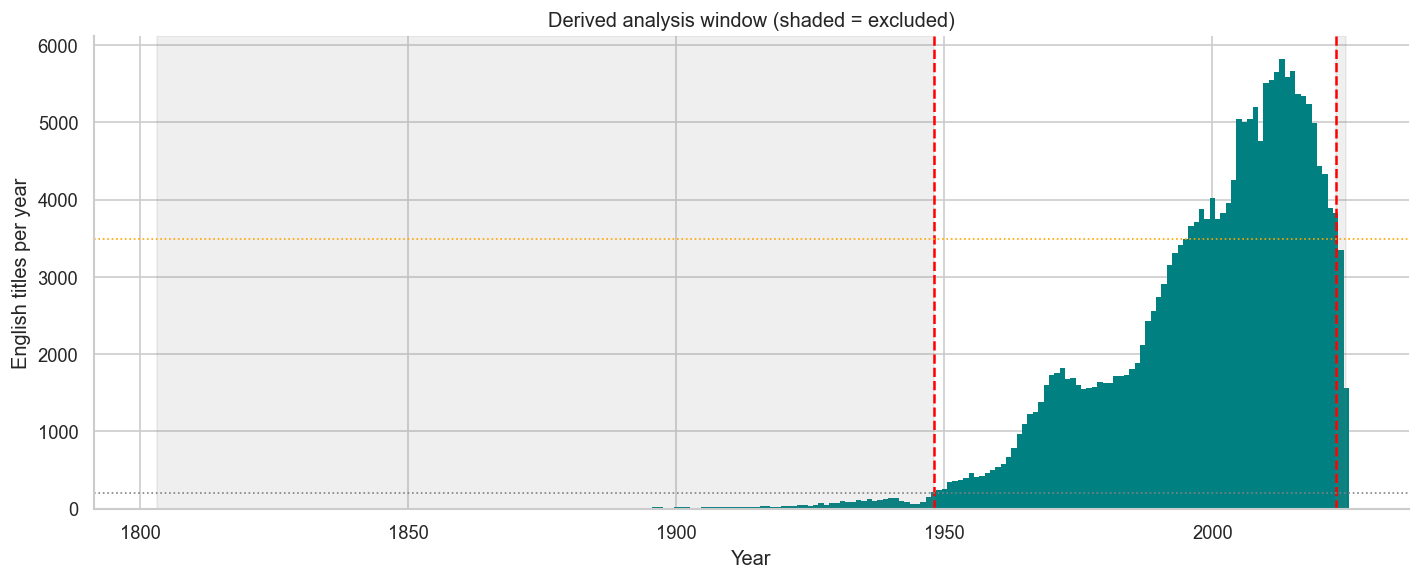

In [6]:
# %% [dynamic year window] derive START_YEAR / TREND_END from the English data
# Rules, not magic numbers:
#   START_YEAR = first year with enough titles for a stable yearly share
#   TREND_END  = last year before the data-entry lag drop-off

MIN_TITLES_PER_YEAR = 200    # floor for a usable year
LAG_DROP_FRAC       = 0.60   # cut tail once counts fall below this fraction of peak

per_year = (
    df_en.assign(year=lambda d: d["year"].astype(int))
    .query("1800 <= year <= 2025")
    .groupby("year")
    .size()
    .sort_index()
)

# START_YEAR: first year at or above the floor
START_YEAR = int(per_year[per_year >= MIN_TITLES_PER_YEAR].index.min())

# TREND_END: walk forward from the peak, keep years still above the lag threshold
peak_year = int(per_year.idxmax())
peak_val  = int(per_year.max())
tail = per_year[per_year.index >= peak_year]
TREND_END = int(tail[tail >= LAG_DROP_FRAC * peak_val].index.max())

usable = per_year[(per_year.index >= START_YEAR) & (per_year.index <= TREND_END)]
print(f"Peak year:        {peak_year} ({peak_val:,} titles)")
print(f"START_YEAR:       {START_YEAR}")
print(f"TREND_END:        {TREND_END}")
print(f"Usable titles:    {usable.sum():,} ({usable.sum() / len(df_en):.1%} of English set)")

# %% [plot] derived window on the full curve
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(per_year.index, per_year.values, color="teal", edgecolor="none", width=1.0)
ax.axvline(START_YEAR, color="red", linestyle="--", linewidth=1.5)
ax.axvline(TREND_END, color="red", linestyle="--", linewidth=1.5)
ax.axhline(MIN_TITLES_PER_YEAR, color="gray", linestyle=":", linewidth=1)
ax.axhline(LAG_DROP_FRAC * peak_val, color="orange", linestyle=":", linewidth=1)
ax.axvspan(per_year.index.min(), START_YEAR, color="gray", alpha=0.12)
ax.axvspan(TREND_END, per_year.index.max(), color="gray", alpha=0.12)
ax.set_xlabel("Year")
ax.set_ylabel("English titles per year")
ax.set_title("Derived analysis window (shaded = excluded)")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

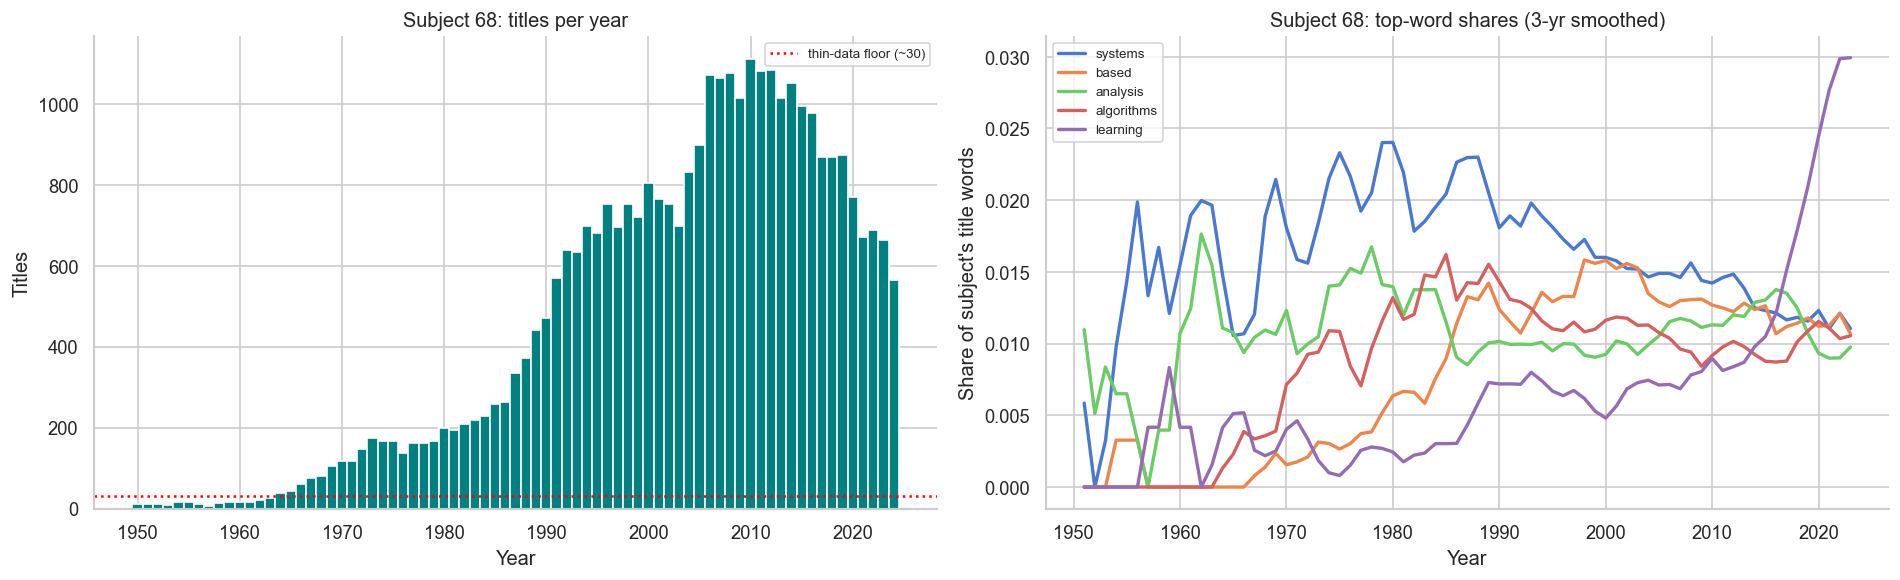

Subject 68: last year with >=30 titles = 2024


In [7]:
# %% per-subject usable window: volume + word-share stability
SUBJECT = "68"   # change per subject

sub = (
    df_en[df_en["code"] == SUBJECT]
    .assign(year=lambda d: d["year"].astype(int))
    .query("1950 <= year <= 2024")
)

# titles per year within this subject
sub_per_year = sub.groupby("year").size()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# left: volume within the subject
axes[0].bar(sub_per_year.index, sub_per_year.values, color="teal", width=1.0)
axes[0].axhline(30, color="red", linestyle=":", label="thin-data floor (~30)")
axes[0].set_title(f"Subject {SUBJECT}: titles per year")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Titles")
axes[0].legend(fontsize=8); sns.despine(ax=axes[0])

# right: a few top words' share within the subject over time
from collections import Counter
def toks(t):
    return [w for w in re.findall(r"[a-z]{4,}", t.lower())]

words_by_year, total_by_year = {}, {}
for y, t in zip(sub["year"], sub["thesis"]):
    ws = toks(t)
    words_by_year.setdefault(y, Counter()).update(ws)
    total_by_year[y] = total_by_year.get(y, 0) + len(ws)

overall = Counter()
for c in words_by_year.values():
    overall.update(c)
top_words = [w for w, _ in overall.most_common(60) if len(w) > 4][:5]

years = sorted(words_by_year)
for w in top_words:
    sh = [words_by_year[y].get(w, 0) / max(total_by_year[y], 1) for y in years]
    axes[1].plot(years, pd.Series(sh, index=years).rolling(3, center=True).mean(),
                 linewidth=2, label=w)
axes[1].set_title(f"Subject {SUBJECT}: top-word shares (3-yr smoothed)")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Share of subject's title words")
axes[1].legend(fontsize=8); sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

print(f"Subject {SUBJECT}: last year with >=30 titles = "
      f"{int(sub_per_year[sub_per_year >= 30].index.max())}")

In [8]:
# tunable parameters
START_YEAR   = 1950   # before this, titles are too sparse to trust shares
TREND_END    = 2018  # cut the post-2018 data-entry lag tail
MIN_TOTAL    = 300    # min total occurrences for a word to be considered
RECENT       = 10     # length of the recent window for the slope (years)
MIN_RECENT_N = 50     # min occurrences inside the recent window to trust the slope
MIN_WORD_LEN = 4      # token regex length floor; raising cuts more short filler
TOP_K        = 15     # how many rising words to show

In [9]:
#!pip install spacy
#!pip install click
#!python -m spacy download en_core_web_sm


In [12]:
import pickle
from gensim.models.phrases import Phraser

# load bigram model built in build_parquets
with open("data/bigram_model.pkl", "rb") as f:
    bigram = pickle.load(f)

def tokenize_doc(doc):
    unigrams = [
        token.lemma_ for token in doc
        if token.pos_ in KEEP_POS
        and not token.is_stop
        and len(token.lemma_) >= 4
    ]
    return list(bigram[unigrams])   # applies bigram detection

# load precomputed global counts from build_parquets -- no need to rerun
_g            = pd.read_parquet("data/global_counts.parquet")
global_counts = Counter(dict(zip(_g["lemma"], _g["count"])))
global_total  = int(_g["count"].sum())
print(f"Global vocabulary: {len(global_counts):,} lemmas | {global_total:,} total tokens")

Global vocabulary: 41,384 lemmas | 1,209,297 total tokens


In [13]:
# %% [per-subject rising-word detection]
MIN_TOTAL      = 10
TREND_END      = 2024
RECENT         = 10
SPECIFICITY    = 1.5   # word must appear 1.5x more in subject than globally
SUBJECT        = "68"

sub_df = df_en[df_en["code"] == SUBJECT].reset_index(drop=True)

titles_clean = [strip_accents(str(t).lower()) for t in sub_df["thesis"]]
years_list   = sub_df["year"].tolist()

year_word, year_total = {}, {}
for year, doc in zip(years_list, nlp.pipe(titles_clean, batch_size=512, n_process=1)):
    toks = tokenize_doc(doc)
    year_word.setdefault(year, Counter()).update(toks)
    year_total[year] = year_total.get(year, 0) + len(toks)

overall = Counter()
for c in year_word.values():
    overall.update(c)

subject_total_words = sum(year_total.values())

def is_specific(word, count):
    subject_share = count / max(subject_total_words, 1)
    global_share  = global_counts[word] / max(global_total, 1)
    return (subject_share / max(global_share, 1e-9)) >= SPECIFICITY

common_words = {
    w for w, n in overall.items()
    if n >= MIN_TOTAL and is_specific(w, n)
}
print(f"Subject {SUBJECT}: {len(common_words)} specific words above MIN_TOTAL")

recent_years = [
    y for y in range(TREND_END - RECENT + 1, TREND_END + 1)
    if year_total.get(y, 0) > 0
]

def score_word(w):
    shares = [year_word[y].get(w, 0) / year_total[y] for y in recent_years]
    if len(shares) < 5:
        return None
    slope = np.polyfit(range(len(shares)), shares, 1)[0] * 10 * 100
    return {"word": w, "recent_slope": slope, "total": overall[w]}

rows = Parallel(n_jobs=-1, prefer="threads")(
    delayed(score_word)(w) for w in common_words
)

rising = (
    pd.DataFrame([r for r in rows if r is not None])
    .dropna()
    .query("recent_slope > 0")
    .nlargest(15, "recent_slope")
)

print(rising.round(3).to_string(index=False))

Subject 68: 1214 specific words above MIN_TOTAL
                   word  recent_slope  total
       machine_learning         0.770    347
               learning         0.724    679
          deep_learning         0.649    180
         neural_network         0.410    278
              algorithm         0.319   2299
                  learn         0.295    764
 reinforcement_learning         0.285    145
          machine_learn         0.254    154
            explainable         0.219     29
              efficient         0.213   1131
                 neural         0.208    117
                   deep         0.194    114
                explore         0.183    126
artificial_intelligence         0.160     65
                   task         0.159    262


In [14]:
# after building `rising`, post-process in two steps

# 1. deduplicate lemma variants: if word A is a prefix of word B and both appear,
#    keep whichever has higher total count
def deduplicate_lemmas(df):
    words_by_total = df.sort_values("total", ascending=False)["word"].tolist()
    keep = []
    for w in words_by_total:
        dominated = any(
            w.startswith(kept) or kept.startswith(w)
            for kept in keep
        )
        if not dominated:
            keep.append(w)
    return df[df["word"].isin(keep)]

# 2. drop words above a global frequency ceiling
#    these are too common corpus-wide to be meaningful signals
MAX_GLOBAL_SHARE = 0.05   # word appears in >0.5% of ALL title words = generic

def below_global_ceiling(word):
    return (global_counts[word] / global_total) < MAX_GLOBAL_SHARE

rising = (
    pd.DataFrame([r for r in rows if r is not None])
    .dropna()
    .query("recent_slope > 0")
    .pipe(deduplicate_lemmas)
    .loc[lambda d: d["word"].map(below_global_ceiling)]
    .nlargest(15, "recent_slope")
)

print(rising.round(3).to_string(index=False))

                   word  recent_slope  total
          deep_learning         0.649    180
         neural_network         0.410    278
              algorithm         0.319   2299
                  learn         0.295    764
 reinforcement_learning         0.285    145
            explainable         0.219     29
              efficient         0.213   1131
                explore         0.183    126
artificial_intelligence         0.160     65
                   task         0.159    262
             multimodal         0.159     57
        decision_making         0.150     80
                enhance         0.148    184
              knowledge         0.144    581
          interpretable         0.141     20


In [15]:
# score = recent_slope * specificity_ratio / log(global_frequency)
# words that are both generic AND not specific get buried

def enriched_score(word, slope, count):
    subject_share = count / max(subject_total_words, 1)
    global_share  = global_counts[word] / max(global_total, 1)
    specificity   = subject_share / max(global_share, 1e-9)
    penalty       = np.log1p(global_counts[word])   # higher global count = more penalty
    return slope * specificity / penalty

rows_scored = Parallel(n_jobs=-1, prefer="threads")(
    delayed(score_word)(w) for w in common_words
)

rising = (
    pd.DataFrame([r for r in rows_scored if r is not None])
    .dropna()
    .query("recent_slope > 0")
    .pipe(deduplicate_lemmas)
    .assign(enriched=lambda d: d.apply(
        lambda r: enriched_score(r["word"], r["recent_slope"], r["total"]), axis=1
    ))
    .nlargest(15, "enriched")   # rank by enriched score, not raw slope
)

print(rising[["word", "recent_slope", "total", "enriched"]].round(3).to_string(index=False))

                   word  recent_slope  total  enriched
          deep_learning         0.649    180     0.439
            explainable         0.219     29     0.338
 reinforcement_learning         0.285    145     0.214
         neural_network         0.410    278     0.183
artificial_intelligence         0.160     65     0.141
            deep_neural         0.129     52     0.139
                  learn         0.295    764     0.138
         internet_thing         0.103     41     0.137
             multimodal         0.159     57     0.136
             multiparty         0.100     33     0.133
             generative         0.137     58     0.118
             blockchain         0.100     30     0.111
                   task         0.159    262     0.107
              algorithm         0.319   2299     0.105
            supervision         0.072     32     0.099


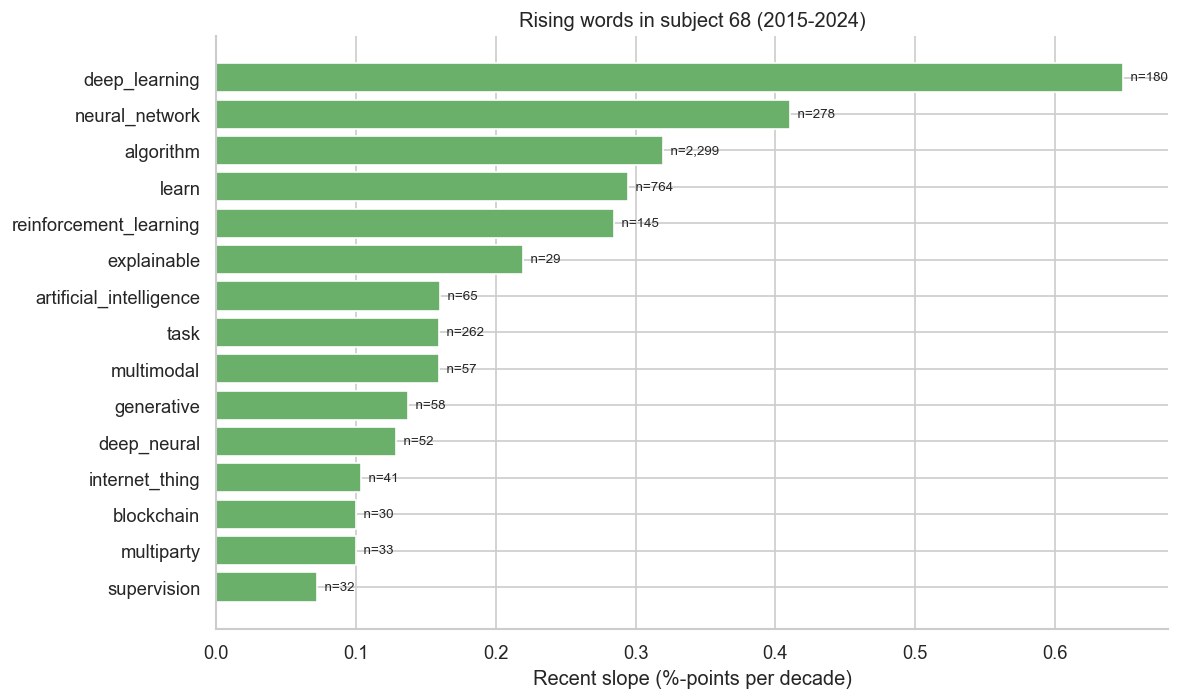

In [16]:
# %% [plot rising words]
fig, ax = plt.subplots(figsize=(10, 6))
d = rising.sort_values("recent_slope")
ax.barh(d["word"], d["recent_slope"], color="#6aaf6a", edgecolor="white")
for i, (_, r) in enumerate(d.iterrows()):
    ax.text(r["recent_slope"], i, f"  n={int(r['total']):,}", va="center", fontsize=8)
ax.set_xlabel("Recent slope (%-points per decade)")
ax.set_title(f"Rising words in subject {SUBJECT} ({recent_years[0]}-{TREND_END})")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

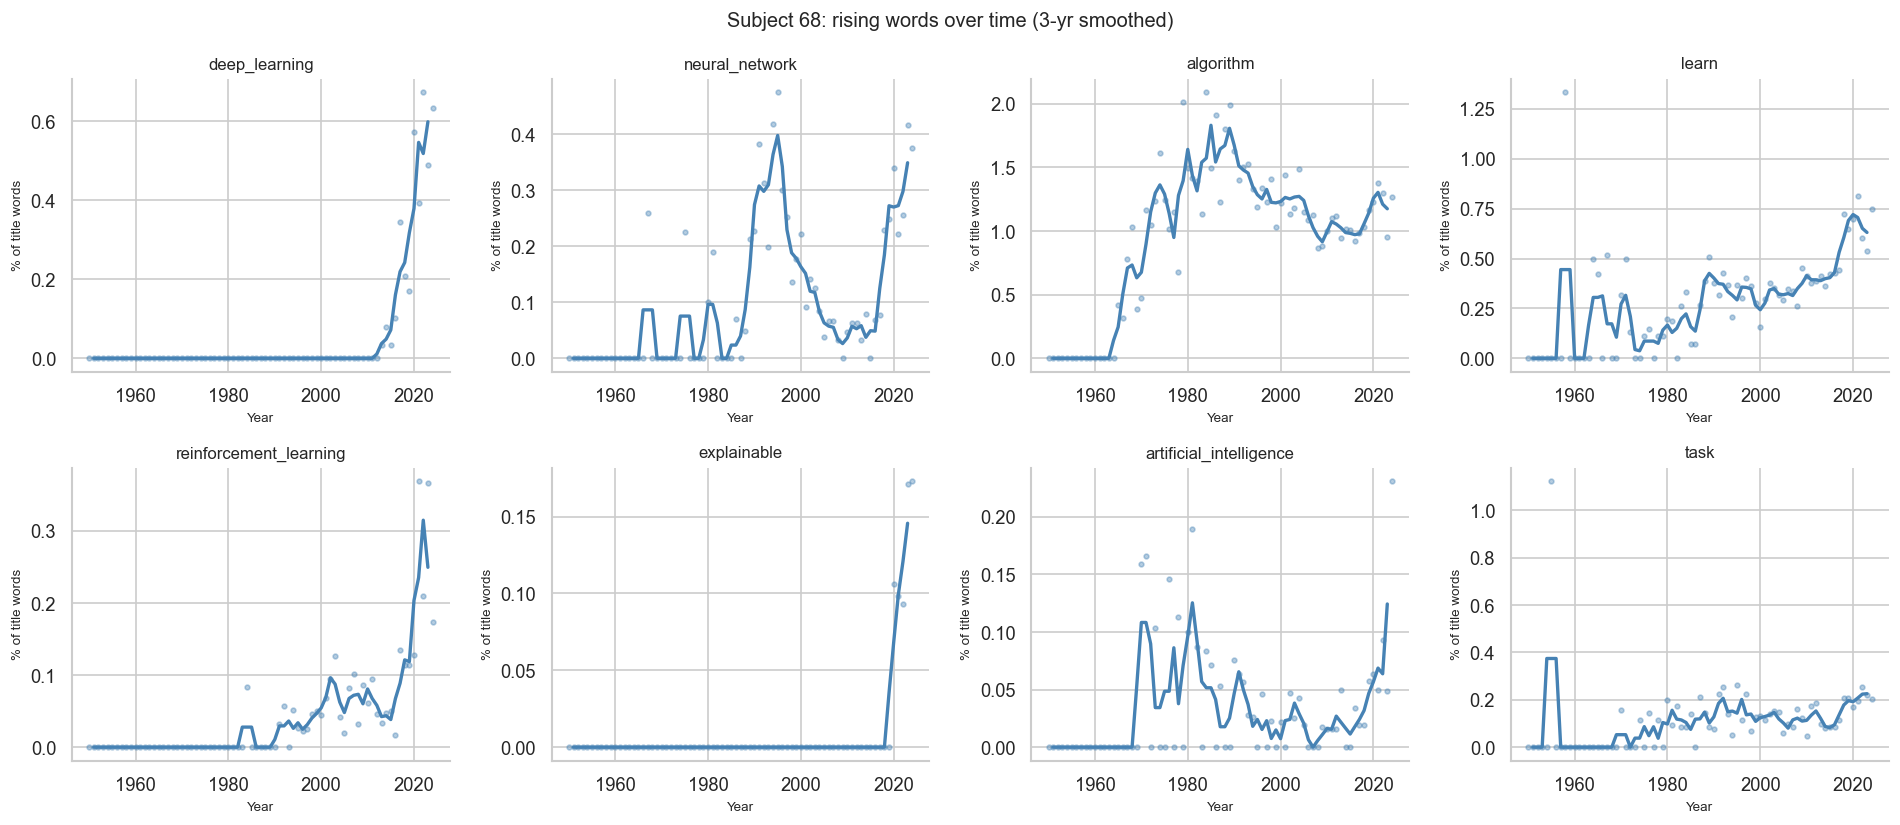

In [17]:
# %% [plot] time series for top rising words in subject SUBJECT
TOP_N = 8
top_words = rising.nlargest(TOP_N, "recent_slope")["word"].tolist()

all_years = sorted(y for y in year_word if START_YEAR <= y <= TREND_END)

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.flatten()

for ax, word in zip(axes, top_words):
    shares = [
        year_word[y].get(word, 0) / max(year_total[y], 1) * 100
        for y in all_years
    ]
    smoothed = pd.Series(shares, index=all_years).rolling(3, center=True).mean()
    ax.plot(all_years, smoothed, linewidth=2, color="steelblue")
    ax.scatter(all_years, shares, s=8, alpha=0.4, color="steelblue")
    ax.set_title(word, fontsize=10)
    ax.set_xlabel("Year", fontsize=8)
    ax.set_ylabel("% of title words", fontsize=8)
    sns.despine(ax=ax)

fig.suptitle(f"Subject {SUBJECT}: rising words over time (3-yr smoothed)", fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
# %% [multi-subject rising word detection]
import pickle

all_subjects = df_en["code"].dropna().unique().tolist()
all_results  = []

for subject in all_subjects:
    sub_df = df_en[df_en["code"] == subject].reset_index(drop=True)
    if len(sub_df) < 100:
        continue

    # load precomputed counts from build_parquets instead of re-tokenizing
    pkl_path = Path("data/subject_counts") / f"{subject}.pkl"
    if not pkl_path.exists():
        print(f"Skipping {subject} -- pkl not found, build_parquets may still be running")
        continue

    with open(pkl_path, "rb") as f:
        counts = pickle.load(f)
    year_word  = counts["year_word"]
    year_total = counts["year_total"]

    overall = Counter()
    for c in year_word.values():
        overall.update(c)

    subject_total_words = sum(year_total.values())

    common_words = {
        w for w, n in overall.items()
        if n >= MIN_TOTAL and is_specific(w, n)
    }

    recent_years = [
        y for y in range(TREND_END - RECENT + 1, TREND_END + 1)
        if year_total.get(y, 0) > 0
    ]

    def score_word(w):
        shares = [year_word[y].get(w, 0) / year_total[y] for y in recent_years]
        if len(shares) < 5:
            return None
        slope = np.polyfit(range(len(shares)), shares, 1)[0] * 10 * 100
        spec  = (overall[w] / max(subject_total_words, 1)) / max(global_counts[w] / global_total, 1e-9)
        enr   = slope * spec / np.log1p(global_counts[w])
        return {"subject": subject, "word": w, "recent_slope": slope,
                "total": overall[w], "enriched": enr}

    rows = Parallel(n_jobs=-1, prefer="threads")(
        delayed(score_word)(w) for w in common_words
    )

    subject_rising = (
        pd.DataFrame([r for r in rows if r is not None])
        .dropna()
        .query("recent_slope > 0")
        .pipe(deduplicate_lemmas)
        .nlargest(10, "enriched")
    )
    subject_rising["subject_name"] = code_to_name.get(subject, subject)
    all_results.append(subject_rising)

results_df = pd.concat(all_results, ignore_index=True)
results_df.to_parquet("data/rising_words_all_subjects.parquet")
print(f"Done: {len(results_df)} rising words across {results_df['subject'].nunique()} subjects")

Done: 586 rising words across 63 subjects


C:\Users\Work\AppData\Local\Temp\ipykernel_49912\3419242208.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(5, "enriched"))


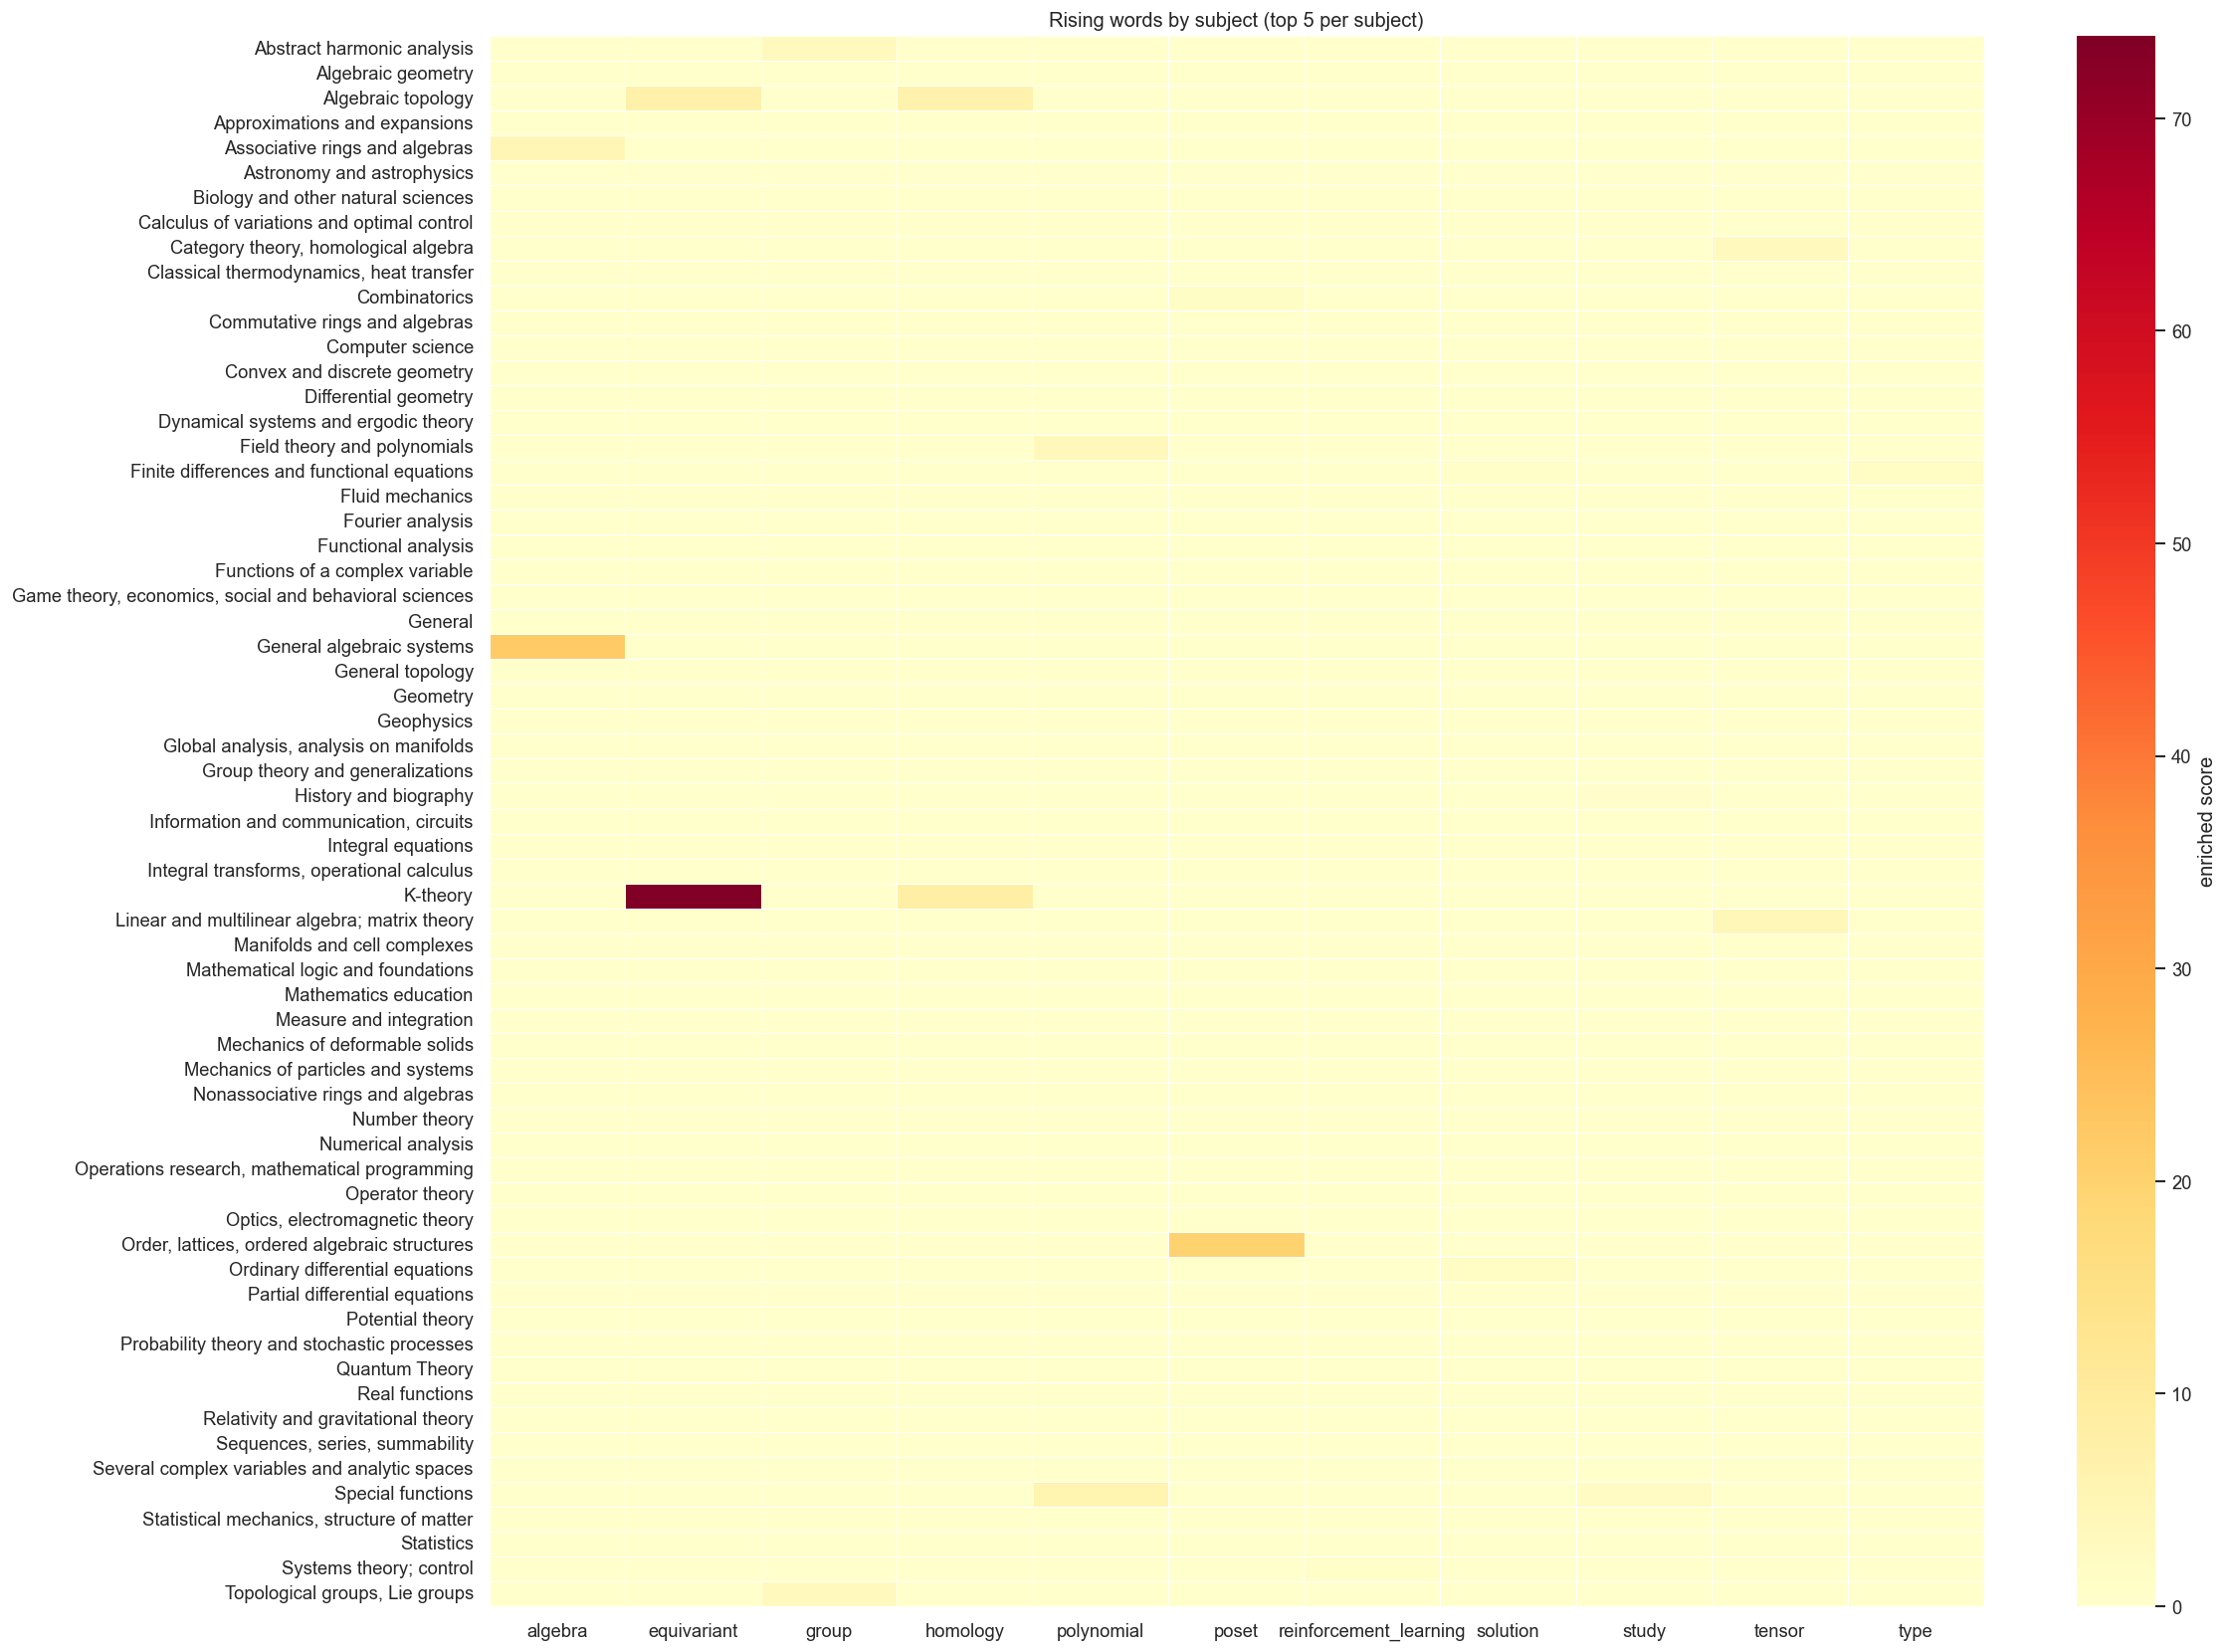

In [20]:
# %% [heatmap: top rising words per subject]
# pivot: rows = subjects, cols = words, values = enriched score
top_per_subject = (
    results_df.groupby("subject_name")
    .apply(lambda x: x.nlargest(5, "enriched"))
    .reset_index(drop=True)
)

pivot = (
    top_per_subject
    .pivot_table(index="subject_name", columns="word", values="enriched", fill_value=0)
)

# keep only words that appear in at least 2 subjects to reduce clutter
pivot = pivot.loc[:, (pivot > 0).sum() >= 2]

fig, ax = plt.subplots(figsize=(20, 14))
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", linewidths=0.3,
            cbar_kws={"label": "enriched score"})
ax.set_title("Rising words by subject (top 5 per subject)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

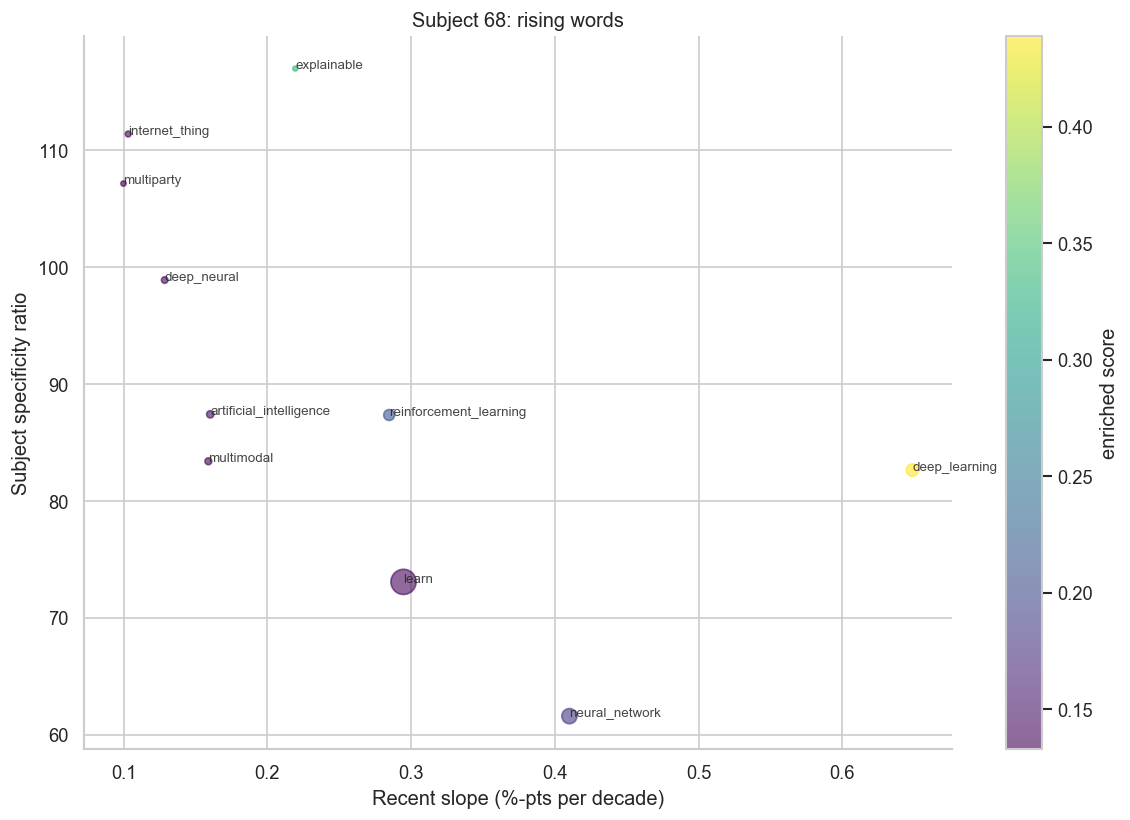

In [21]:
# %% [bubble chart for one subject]
SUBJECT = "68"
sub = results_df[results_df["subject"] == SUBJECT].copy()
sub["specificity"] = sub.apply(
    lambda r: (r["total"] / subject_total_words) / max(global_counts[r["word"]] / global_total, 1e-9),
    axis=1
)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(sub["recent_slope"], sub["specificity"],
                s=sub["total"] * 0.3, alpha=0.6, c=sub["enriched"], cmap="viridis")
for _, row in sub.iterrows():
    ax.annotate(row["word"], (row["recent_slope"], row["specificity"]),
                fontsize=8, alpha=0.85)
plt.colorbar(sc, ax=ax, label="enriched score")
ax.set_xlabel("Recent slope (%-pts per decade)")
ax.set_ylabel("Subject specificity ratio")
ax.set_title(f"Subject {SUBJECT}: rising words")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

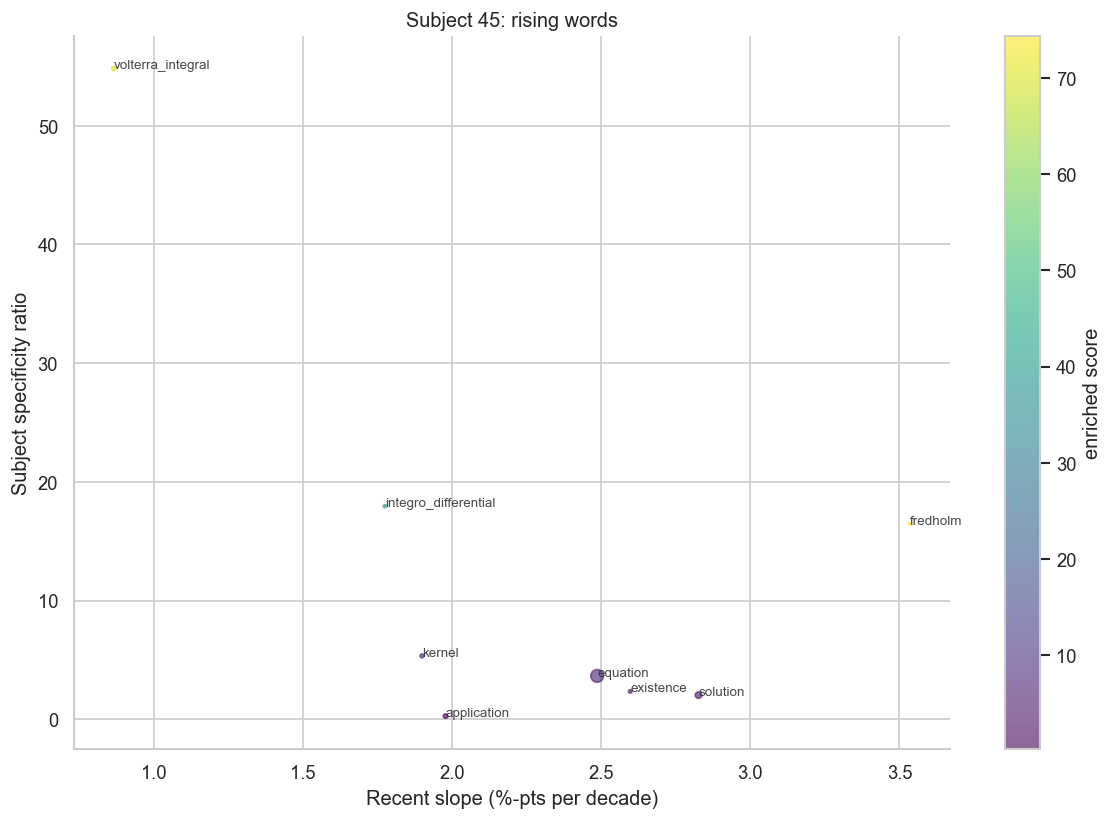

In [22]:
# %% [bubble chart for one subject]
SUBJECT = "45"
sub = results_df[results_df["subject"] == SUBJECT].copy()
sub["specificity"] = sub.apply(
    lambda r: (r["total"] / subject_total_words) / max(global_counts[r["word"]] / global_total, 1e-9),
    axis=1
)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(sub["recent_slope"], sub["specificity"],
                s=sub["total"] * 0.3, alpha=0.6, c=sub["enriched"], cmap="viridis")
for _, row in sub.iterrows():
    ax.annotate(row["word"], (row["recent_slope"], row["specificity"]),
                fontsize=8, alpha=0.85)
plt.colorbar(sc, ax=ax, label="enriched score")
ax.set_xlabel("Recent slope (%-pts per decade)")
ax.set_ylabel("Subject specificity ratio")
ax.set_title(f"Subject {SUBJECT}: rising words")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

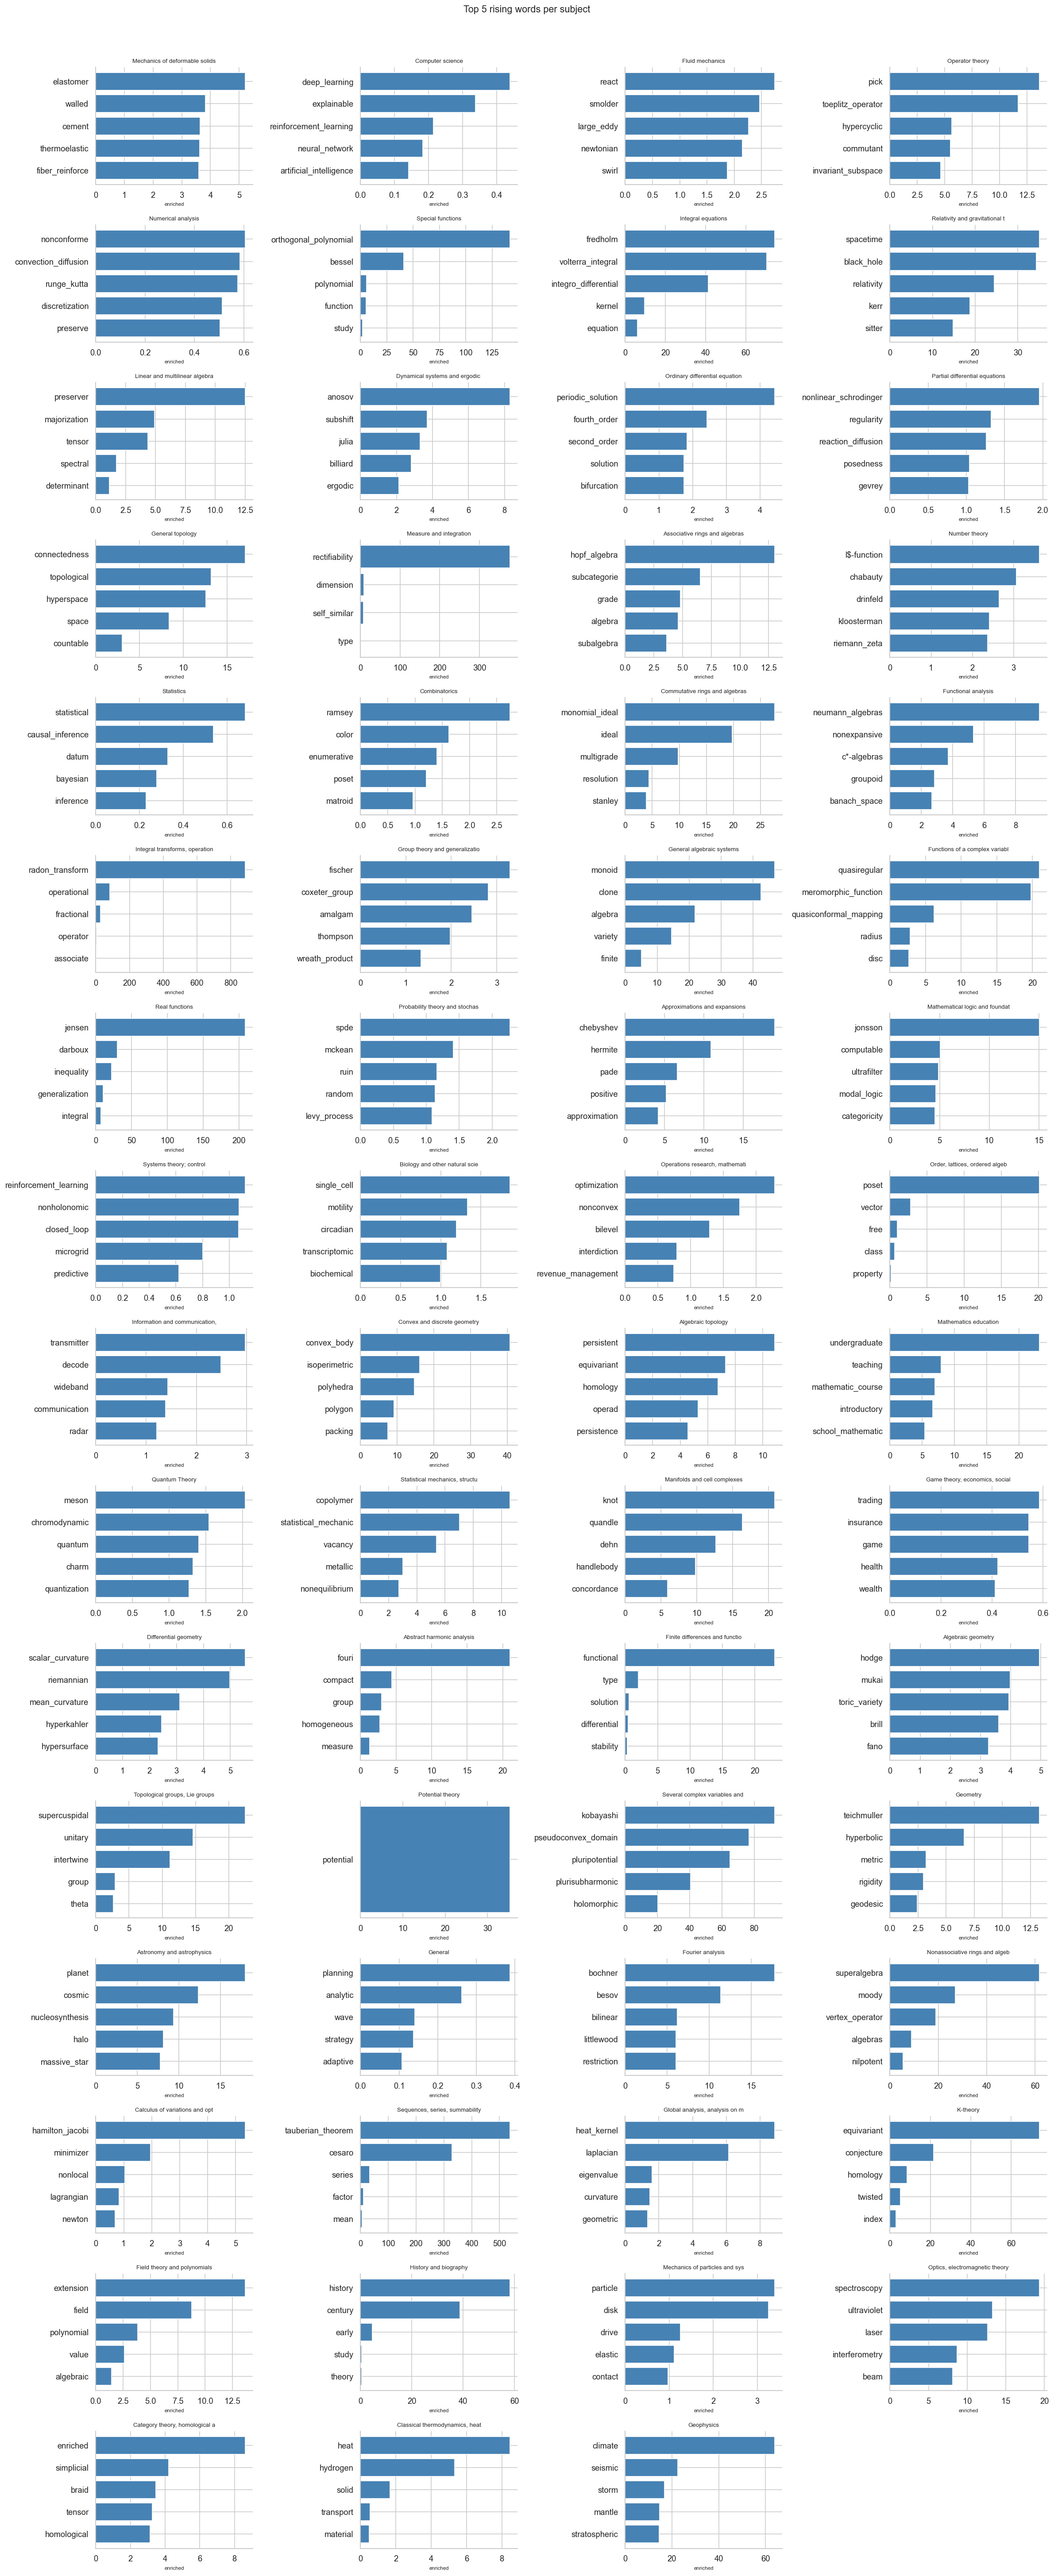

In [23]:
# %% [small multiples: top 5 per subject]
subjects = results_df["subject_name"].unique()
ncols = 4
nrows = -(-len(subjects) // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3))
axes = axes.flatten()

for ax, subj in zip(axes, subjects):
    sub = (results_df[results_df["subject_name"] == subj]
           .nlargest(5, "enriched")
           .sort_values("enriched"))
    ax.barh(sub["word"], sub["enriched"], color="steelblue")
    ax.set_title(subj[:30], fontsize=8)
    ax.set_xlabel("enriched", fontsize=7)
    sns.despine(ax=ax)

for ax in axes[len(subjects):]:
    ax.set_visible(False)

plt.suptitle("Top 5 rising words per subject", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()